# Machine Learning 0 - Introduction

In this lab, we will introduce the classification problem that we will be working on for the last three labs. The objectives of the lab are:

* Examine the dataset and prepare the basic pipeline that will be used in the next lab.
* Make sure that we use a correct methodology for comparing the algorithms
* Get used to working with the [scikit-learn](https://scikit-learn.org/stable/) library.

## Important note

For the machine learning labs, **each student must write a report** (one report for all labs together) which will be used during the oral exam. This report should highlight the different methods used during the labs, but also how you validated each method and compared their results.

## Introduction to the dataset

The [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) dataset has been collected by Alex Krizhevsky, Vinod Nair, and Geoffrey Hinton. It consists of 60.000 32x32 colour images, split in 10 classes: 'airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'.

*Reference: Learning Multiple Layers of Features from Tiny Images, Alex Krizhevsky, 2009.* PDF available at https://www.cs.toronto.edu/~kriz/learning-features-2009-TR.pdf

For the purpose of the INFO-H-501 laboratories, we will use a subset of those images by only taking 3 different classes: 'airplane', 'bird' and 'horse'.

[Click here to download](https://my.pcloud.com/publink/show?code=XZJUCPkZqiVxqtn8CXRB7D78YKt88RJvzWyk) the modified dataset. Extract the ZIP file and put the CIFAR10 folder in the same directory as the notebook.

The images are 32x32 8-bit **RGB**, and from these we extracted **Histogram of Gradient** vectors (16 orientations x 16 blocks = 256 values in HoG vector).

The following code pre-loads all of this data (make sure that you have the [lab_tools.py](https://github.com/odebeir/info-h-500-501/blob/master/LABS1/lab_tools.py) file in the same directory as the notebook, if you didn't clone the repository):

In [1]:
from lab_tools import CIFAR10, get_hog_image

Pre-loading training data
Pre-loading test data


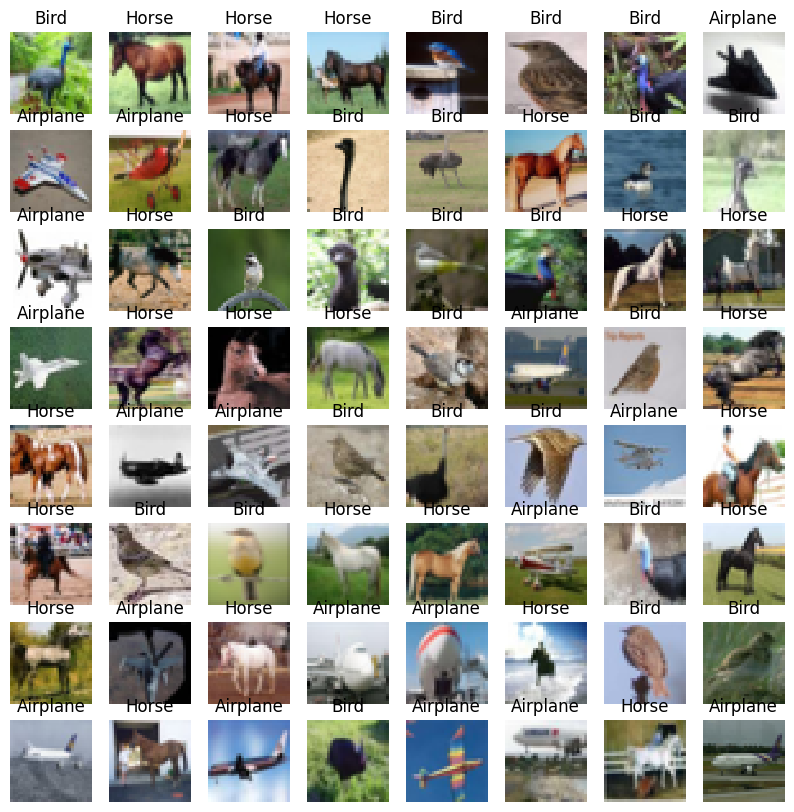

In [4]:
path_CIFAR10 = "C:/Users/regna/Documents/ULB/MA2/Q2/INFO_H501/INFO_H501/docs/LABS/CIFAR10/"
dataset = CIFAR10(path_CIFAR10)
from matplotlib import pyplot as plt
%matplotlib inline

plt.figure(figsize=(10,10))
for i in range(64):
    plt.subplot(8,8,i+1)
    plt.imshow(dataset.train['images'][i].reshape((32,32,3)), interpolation='none')
    plt.title(dataset.labels[dataset.train['labels'][i]])
    plt.axis('off')
plt.show()

We can also have a look at some HoG images:

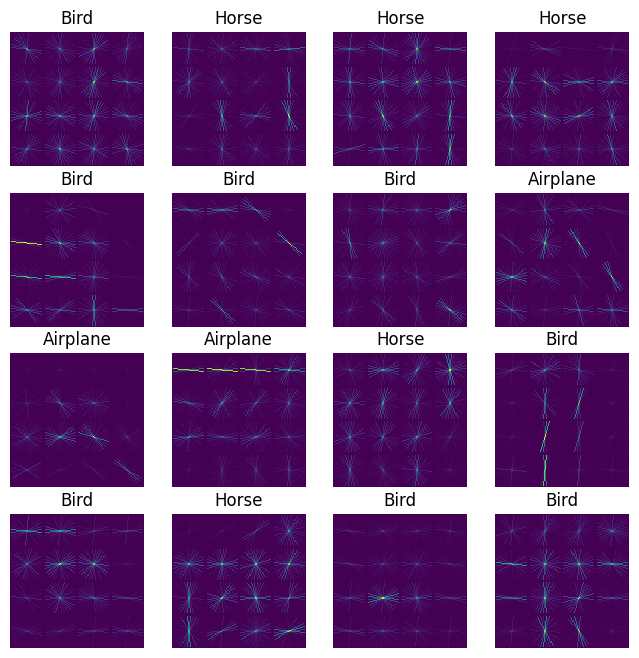

In [5]:
plt.figure(figsize=(8,8))
for i in range(16):
    plt.subplot(4,4,i+1)
    hog = dataset.train['hog'][i].reshape((4,4,16))
    plt.imshow(get_hog_image(hog, 128), interpolation='none')
    plt.title(dataset.labels[dataset.train['labels'][i]])
    plt.axis('off')
plt.show()

Note that this is an "image" representation of the HoG, but that the actual data that we will be working on is a size 256 vector for each image. Our **feature space** has therefore 256 dimensions.

## Exploring the dataset

The *dataset* object gives you access to different attributes:

* *dataset.path* contains the path to the CIFAR10 folder.
* *dataset.labels* contains the name of the three classes
* *dataset.train* and *dataset.test* are dictionaries containing three numpy arrays each:
    * *images* contains the RGB images
    * *hog* contains the HoG vectors
    * *labels* contains the label for each image

In [6]:
print(dataset.path)
print(dataset.labels)
print(dataset.train.keys())
print(dataset.train['hog'].shape)

C:/Users/regna/Documents/ULB/MA2/Q2/INFO_H501/INFO_H501/docs/LABS/CIFAR10/
['Airplane', 'Bird', 'Horse']
dict_keys(['images', 'hog', 'labels'])
(15000, 256)


### Quick questions:

The dataset has already been split into a training set (dataset.train) and a test set (dataset.test).

* How many images are in the training set ?
* How many images are in the test set ?
* What is the class distribution of the dataset ?

15000
3000


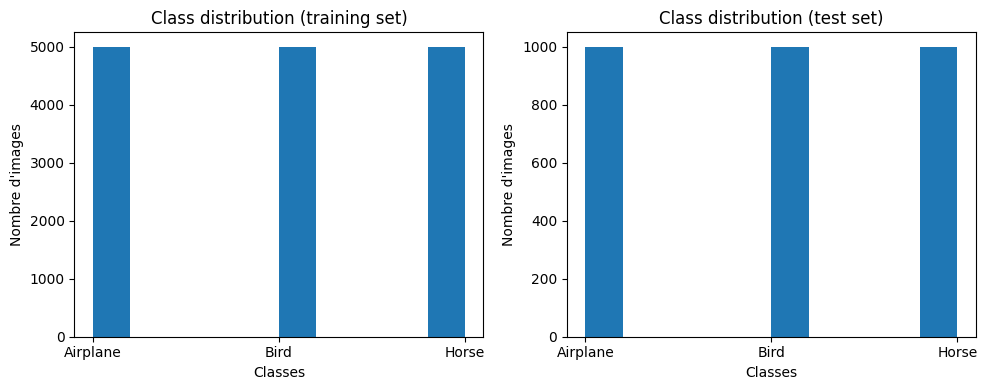

In [7]:
import numpy as np
nb_img_training = dataset.train['images'].shape[0]
print(nb_img_training)

nb_img_test = dataset.test['images'].shape[0]
print(nb_img_test)


labels_train = dataset.train['labels']
labels_test = dataset.test['labels']
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(labels_train)
plt.xticks(range(len(dataset.labels)), dataset.labels)
plt.title("Class distribution (training set)")
plt.xlabel("Classes")
plt.ylabel("Nombre d'images")

plt.subplot(1,2,2)
plt.hist(labels_test)
plt.xticks(range(len(dataset.labels)), dataset.labels)
plt.title("Class distribution (test set)")
plt.xlabel("Classes")
plt.ylabel("Nombre d'images")

plt.tight_layout()
plt.show()


*Dataset is well balanced so the accuracy is a pretty good metrics to analyze the model performance.*

### Descriptive data analysis

Look at the HoG data from the training set. What are the characteristics of the dataset ? Do you think that some pre-processing may be required to help with the different algorithms ?

(256,)


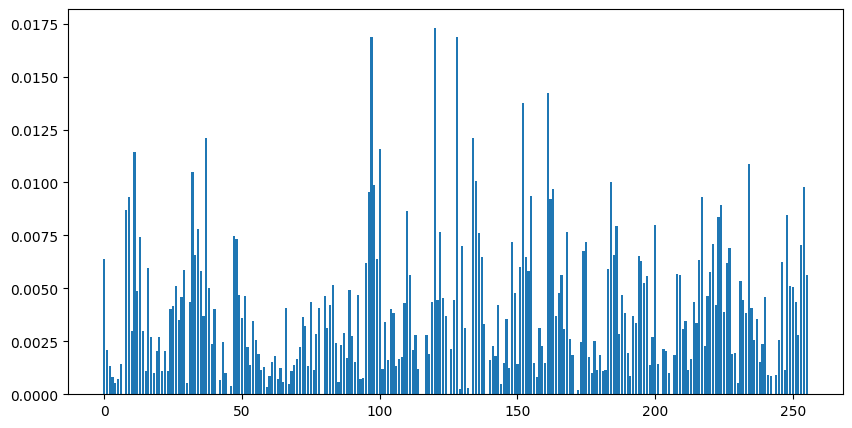

In [8]:
print(dataset.train['hog'][0].shape)
plt.figure(figsize=(10,5))
plt.bar(range(256), dataset.train['hog'][0]) #Just for one image (256 dimensions)
plt.show()


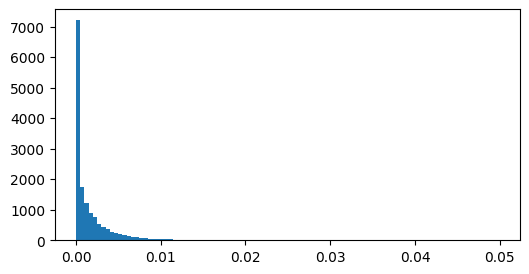

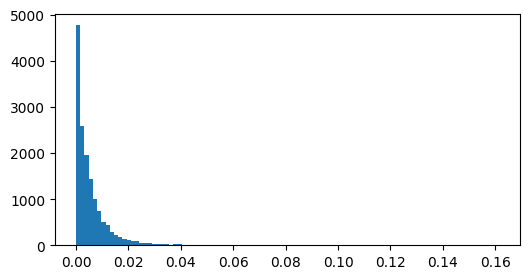

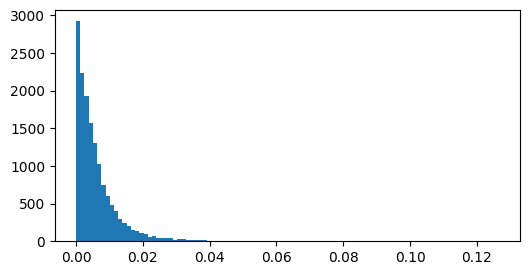

In [9]:
plt.figure(figsize=(6,3))
plt.hist(dataset.train['hog'][:, 50], bins=100) #Feature 50 pour toutes les images
plt.figure(figsize=(6,3))
plt.hist(dataset.train['hog'][:, 100], bins=100)
plt.figure(figsize=(6,3))
plt.hist(dataset.train['hog'][:, 150], bins=100)
plt.show()



*The distributions of one dimension are very similar with a lot of value close to 0 and an exponenatial decreasing in similar range. Preprocessing may be required because values are not centred on the origin. There are also a lot of dimension so we could look at some correlation to reduce the dimension of feature space.*

## Introduction to scikit-learn

[Scikit-learn](https://scikit-learn.org/stable/) is a very well documented machine learning library in Python. It contains many algorithms for [classification](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning), and makes the whole process of building a machine learning pipeline relatively straightforward. There are many examples in the documentation, as well as relatively complete theoretical explanations, so I really encourage you to take the time to read it if some things are not clear.

Let's make a very simple example. We are going to use the [Ridge Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeClassifier.html#sklearn.linear_model.RidgeClassifier), which is a very basic linear model.

In [10]:
from sklearn.linear_model import RidgeClassifier

To use a classifier with scikit-image, we generally have three steps:

* Create an instance of the class of the classifier (here: RidgeClassifier). The constructor will generally contain many arguments that can be modified, and that are explained in the documentation. There will also generally be default values for all of them, so in this simple example we will just use those:

In [11]:
clf = RidgeClassifier()

* Use the *fit* method with, as arguments, the training data (in our case, the HoG vectors) and the corresponding labels. This will start the main training algorithm, trying to fit the parameters of the classifier with the training data:

In [12]:
clf.fit(dataset.train['hog'], dataset.train['labels'])

,"alpha alpha: float, default=1.0Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.For an illustration of the effect of alpha on the model coefficients, see:ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If set to false, nointercept will be used in calculations (e.g. data is expected to bealready centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.The default value is determined by scipy.sparse.linalg.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard scipy.linalg.solve function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in scipy.sparse.linalg.cg. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine scipy.sparse.linalg.lsqr. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its unbiased and more flexible version named SAGA. Both methods use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from sklearn.preprocessing. .. versionadded:: 0.17 Stochastic Average Gradient descent solver. .. versionadded:: 0.19 SAGA solver.- 'lbfgs' uses L-BFGS-B algorithm implemented in `scipy.optimize.minimize`. It can be used only when `positive` is True.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary <random_state>` for details.",None
Name,Type,Value
"classes_ classes_: ndarray of shape (n_class

* Use the *predict* method to get the prediction of the classifier on the data given as argument. In this case, we get the predictions on the data that was just used for training. **What kind of performance will that give us?**

In [13]:
pred = clf.predict(dataset.train['hog'])
print(pred.shape)

(15000,)


We can then evaluate those predictions. Scikit-learn provides many different [metrics](https://scikit-learn.org/stable/modules/model_evaluation.html) for evaluating the performances of a classifier. The most simple of those is the accuracy, which is simply the number of correct predictions divided by the total number of predictions:

In [14]:
from sklearn.metrics import accuracy_score

score = accuracy_score(dataset.train['labels'], pred)
print(score)

# Not that it's fairly easy to compute that score "by hand":
T = (pred==dataset.train['labels']).sum()
print(T, len(pred), T/len(pred))

0.7356666666666667
11035 15000 0.7356666666666667


In a multiclass problem, it's often also very useful to look at the [confusion matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html#sklearn.metrics.confusion_matrix), which gives us more information on which classes are often mistaken for each other:

In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(dataset.train['labels'], pred)
print(cm)

[[3812  740  448]
 [ 742 3236 1022]
 [ 337  676 3987]]


*Usefull to justify if errors are randomly distrbuted or not.*

Note that the rows represent the **true labels** and the columns the **predicted labels**. So this mean that, in this case, out of the 5000 images of class 0 ("Airplane"), 3812 were correctly classified, 740 were classified as "Bird" and 448 as "Horse").

### Quick question

* Modify the code to estimate the **predictive** performance of the algorithm (without using the test set).

In [16]:
#Use 10% of training set
p_val = 0.1
n_val = int(p_val*len(dataset.train['hog']))
print(n_val)

X_train = dataset.train['hog'][:-n_val]
Y_train = dataset.train['labels'][:-n_val]

X_val = dataset.train['hog'][-n_val:]
Y_val = dataset.train['labels'][-n_val:]

print(X_train.shape, Y_train.shape, X_val.shape, Y_val.shape)


1500
(13500, 256) (13500,) (1500, 256) (1500,)


*If we do that be carefull that the dataset have to be not ordered*

In [17]:
clf = RidgeClassifier(alpha=0.1) #pk la on fixe un alpha ?
clf.fit(X_train, Y_train)
pred = clf.predict(X_val)

pred_descr = clf.predict(X_train)
score_descr = accuracy_score(Y_train,pred_descr)
print(f"Descriptive score:{score_descr:.3f}")

score_pred = accuracy_score(Y_val,pred)
print(f"Predictive score:{score_pred:.3f}")

cm = confusion_matrix(Y_val, pred)
print(cm)
print(cm.sum(axis=1))

Descriptive score:0.756
Predictive score:0.742
[[405  65  42]
 [ 67 330  93]
 [ 34  86 378]]
[512 490 498]


*The predictive score is generally lower than the descriptive one. If it is a lot lower, it is a good indication that we are dealing with some overfitting.*

## How can we find the "best" algorithm?

What we have shown above served to illustrate how scikit-learn classifiers work, but we now have to build a valid machine learning pipeline to compare the different algorithms that we will use in the next labs.

As we have said earlier, we have already split the dataset into a "training" and a "test" set. It is clear that the final evaluation should take place on the test set.

But in addition to comparing the algorithms between each other, we also have to find the best "hyper-parameters" for each algorithm. For example, in our RidgeClassifier example, there is a regularization parameters, *alpha*, which by default was set to 1.0. Can we improve the performance of the algorithm by modifying this parameter ?

### Side-note: parameter vs hyper-parameter

In general, when talking about machine learning models, **parameters** are what the algorithm learns with the data (if we are for instance learning a linear regression y = ax+b, the "parameters" would be a and b), while **hyper-parameters** are modifiers to the model or to the pipeline (for instance, if we are generalizing to a polynomial regression, the degree of the polynome would be an hyper-parameter).

### Cross-validation

The most common way of finding the best hyper-parameters of a classifier is to use [cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html).

* Using the [cross_val_score](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html#sklearn.model_selection.cross_val_score) method from scikit-learn, find the best *alpha* hyper-parameter for the RidgeClassifier:

In [18]:

# cross-validation
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV

clf = RidgeClassifier(alpha=0.1)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(clf, dataset.train['hog'], dataset.train['labels'], cv=skf)
print("List of scores :",scores)
print("Mean score of the 5 fold cross validation : ",scores.mean())

# find best alpha parameter
grid = GridSearchCV(clf, param_grid = { "alpha": [0.001, 0.01, 0.1, 1, 10, 100]}, cv=skf, scoring="accuracy")
grid.fit(dataset.train['hog'], dataset.train['labels'])
print("Best alpha :",grid.best_params_)
print(grid.best_score_) # Mean cross-validated score of the best_estimator


List of scores : [0.73333333 0.75366667 0.75233333 0.742      0.74633333]
Mean score of the 5 fold cross validation :  0.7455333333333334
Best alpha : {'alpha': 0.001}
0.7461333333333333


### Comparing algorithms

Once you have found the best hyper-parameters for an algorithm, you can re-train the classifier on the whole training set, and finally use the test set to get a "final performance".

* How can you then decide which of the classifiers is best ?
* How can you decide if the different between two classifiers is significant ?

Try to compare the best RidgeClassifier with the original. Is it significantly better?

In [20]:
from scipy.stats import ttest_rel
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Ridge original
clf1 = RidgeClassifier(alpha=0.1)
scores1 = cross_val_score(clf1, dataset.train['hog'],
                          dataset.train['labels'], cv=skf)

# Ridge optimisé
clf2 = RidgeClassifier(alpha=0.001)
scores2 = cross_val_score(clf2, dataset.train['hog'],
                          dataset.train['labels'], cv=skf)

print("Original :", scores1.mean())
print("Optimized :", scores2.mean())

# Test statistique
t, p = ttest_rel(scores1, scores2)

print("p-value =", p)

if p < 0.05:
    print("Difference is significant")
else:
    print("Difference is NOT significant")

Original : 0.7455333333333334
Optimized : 0.7461333333333333
p-value = 0.7945925611252561
Difference is NOT significant
